# Mini Project 4 :- Exploratory Data Analysis of Google Play Store Apps Dataset for Business Insights

In [1]:
# Objective :-
# To perform Exploratory Data Analysis on Google Play Store apps dataset and
# extract meaningful business insights related to app ratings, installs, categories, pricing, and user engagement.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("googleplaystore.csv")

In [4]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [6]:
df.shape

(10841, 13)

In [7]:
df.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


In [8]:
df.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(483)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.shape

(10358, 13)

# Handle missing values

In [12]:
# Rating numerical column hai
# Missing values ko average rating se fill kar rahe hain
# why mean ? beacause.. Rating numerical data hai aur mean dataset ki central tendency represent karta hai.

df["Rating"] = df["Rating"].fillna(df["Rating"].mean())

In [13]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [14]:
df.dropna(subset = ["Type"], inplace=True)

In [15]:
# Content Rating categorical column hai
# Missing value ko sabse frequently occurring value se fill kar rahe hain
# why mode ? qki Categorical data ke liye mode best replacement hota hai.

df["Content Rating"] = df["Content Rating"].fillna(df["Content Rating"].mode()[0])

In [16]:
df["Current Ver"] = df["Current Ver"].fillna("Unknown")

In [17]:
df["Android Ver"] = df["Android Ver"].fillna("Varies with device")

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df.isnull().sum()

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
dtype: int64

In [20]:
# Installs column me , aur + symbol remove kar rahe hain
df["Installs"] = df["Installs"].astype(str)
df["Installs"] = df["Installs"].str.replace(",", "")
df["Installs"] = df["Installs"].str.replace("+", "")
# String ko numeric format me convert kar rahe hain
df["Installs"] = pd.to_numeric(df["Installs"], errors="coerce")

# Installs clean hi kyu kiya aakhir ? ---> : Mathematical calculations aur visualizations ke liye numeric format zaroori tha.

In [21]:
# why we convert price ? ---> Qki Correlation, average aur comparison ke liye numeric format required tha.

df["Price"] = pd.to_numeric(df["Price"].astype(str).str.replace("$", ""), errors="coerce")

In [22]:
df.describe()  # Numerical columns ka summary statistics dekhne ke liye

,Rating,Installs,Price
count,10357.000000,1.035600e+04,10356.000000
mean,4.189542,1.415913e+07,1.030900
std,0.505429,8.024331e+07,16.279408
min,1.000000,0.000000e+00,0.000000
25%,4.100000,1.000000e+03,0.000000
50%,4.200000,1.000000e+05,0.000000
75%,4.500000,1.000000e+06,0.000000
max,19.000000,1.000000e+09,400.000000


In [23]:
df["Category"].unique()

array(['ART_AND_DESIGN', 'AUTO_AND_VEHICLES', 'BEAUTY',
       'BOOKS_AND_REFERENCE', 'BUSINESS', 'COMICS', 'COMMUNICATION',
       'DATING', 'EDUCATION', 'ENTERTAINMENT', 'EVENTS', 'FINANCE',
       'FOOD_AND_DRINK', 'HEALTH_AND_FITNESS', 'HOUSE_AND_HOME',
       'LIBRARIES_AND_DEMO', 'LIFESTYLE', 'GAME', 'FAMILY', 'MEDICAL',
       'SOCIAL', 'SHOPPING', 'PHOTOGRAPHY', 'SPORTS', 'TRAVEL_AND_LOCAL',
       'TOOLS', 'PERSONALIZATION', 'PRODUCTIVITY', 'PARENTING', 'WEATHER',
       'VIDEO_PLAYERS', 'NEWS_AND_MAGAZINES', 'MAPS_AND_NAVIGATION',
       '1.9'], dtype=object)

# Exploratory Data Analysis (EDA)

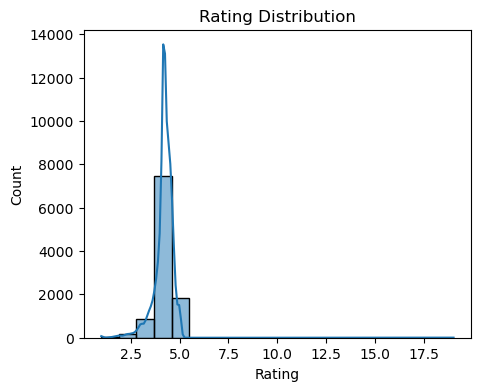

In [24]:
# Ratings kis range me distributed hain dekhne ke liye histogram
plt.figure(figsize=(5,4))
sns.histplot(df["Rating"], bins=20, kde=True)
plt.title("Rating Distribution")
plt.show()

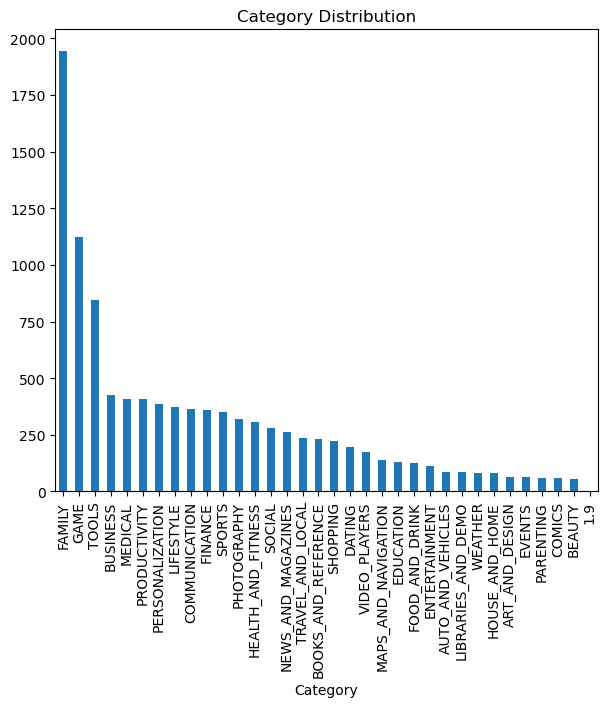

In [25]:
# Kaunsi category me sabse zyada apps hain check karne ke liye
plt.figure(figsize=(7,6))
df["Category"].value_counts().plot(kind="bar")
plt.title("Category Distribution")
plt.show()

<Axes: ylabel='count'>

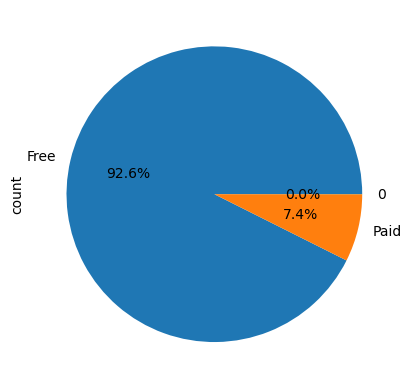

In [26]:
# Free aur Paid apps ka percentage dekhne ke liye
df["Type"].value_counts().plot(kind="pie", autopct="%1.1f%%")

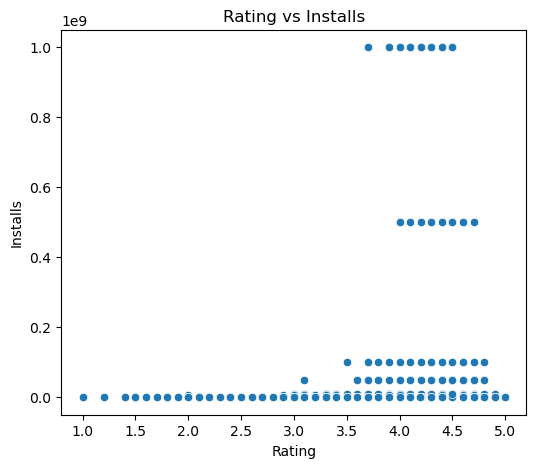

In [27]:
# Rating aur installs ke beech relationship dekhne ke liye
plt.figure(figsize=(6,5))
sns.scatterplot(x="Rating", y="Installs", data=df)
plt.title("Rating vs Installs")
plt.show()

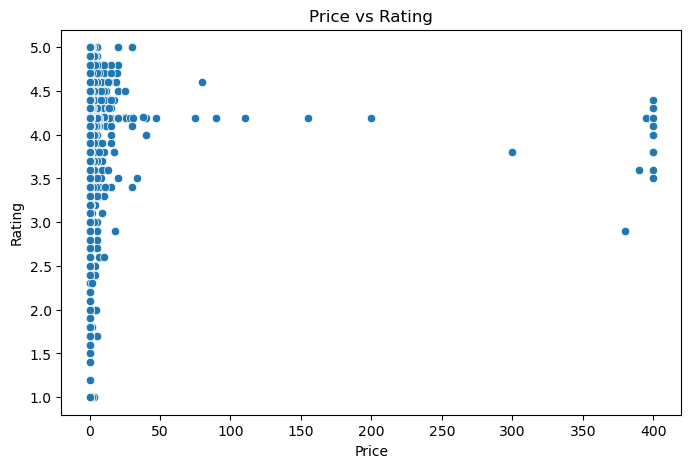

In [28]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="Price", y="Rating", data=df)
plt.title("Price vs Rating")
plt.show()

<Axes: xlabel='Category'>

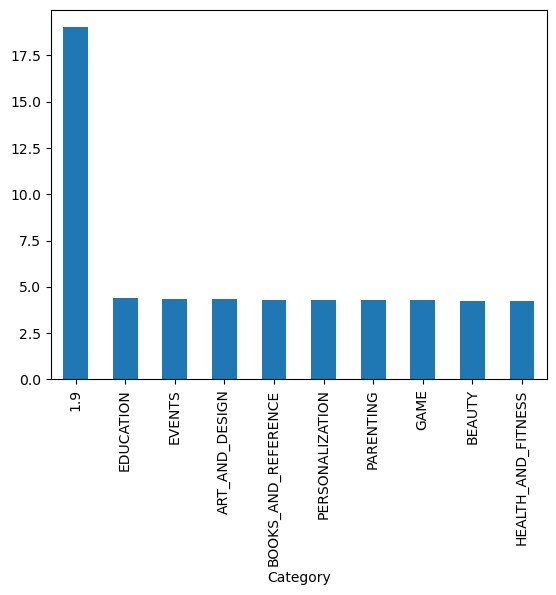

In [29]:
df.groupby("Category")["Rating"].mean().sort_values(ascending=False).head(10).plot(kind="bar")

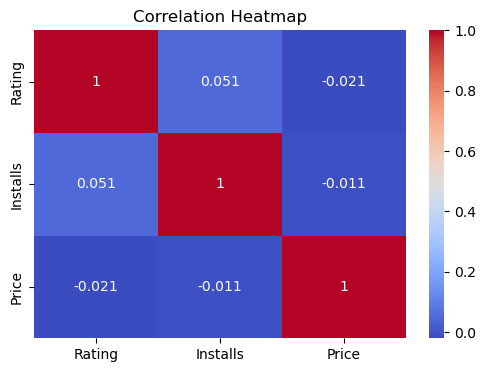

In [30]:
# Numerical columns ke beech correlation check karne ke liye
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Business Insights :-

In [31]:
# Most apps are free → market is dominated by free apps
# Gaming & Family categories are most popular
# High installs ≠ high rating always
# Price has weak relation with rating
# Some categories have consistently high ratings